# Huấn luyện và kiểm thử công bằng: Pre-Norm vs Post-Norm

Notebook này chạy thực nghiệm so sánh theo đúng nguyên tắc công bằng:

- Cùng seed
- Cùng tokenizer
- Cùng hyperparameter
- Chỉ thay đổi kiến trúc chuẩn hóa: `prenorm` và `postnorm`

Kết quả sẽ được lưu vào thư mục `results/` gồm:

- `comparison_results.csv`
- `confusion_matrices.json`

In [ ]:
import os
import sys
import json
import csv
import importlib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


project_root = os.getcwd()
if not os.path.exists(os.path.join(project_root, 'train.py')):
    parent_root = os.path.abspath(os.path.join(project_root, '..'))
    if os.path.exists(os.path.join(parent_root, 'train.py')):
        project_root = parent_root
    else:
        repo_root = os.path.join(project_root, '-DL-Prenorm-Transformer-AGnews')
        if os.path.exists(os.path.join(repo_root, 'train.py')):
            project_root = repo_root
if project_root not in sys.path:
    sys.path.append(project_root)

import train
import evaluate

importlib.reload(train)
importlib.reload(evaluate)

train_loop = train.train_loop
evaluate_checkpoint = evaluate.evaluate_checkpoint

SEED = 42
EPOCHS = 10
BATCH_SIZE = 64
LR = 1e-3
DEVICE = None

USE_HF_TOKENIZER = False
TOKENIZER_NAME = 'distilbert-base-uncased'

TRAIN_SUBSET = None
TEST_SUBSET = None
EARLY_STOP_PATIENCE = 5
EARLY_STOP_MIN_DELTA = 0.0

SEQ_LEN = 128
MAX_VOCAB = 20000

results_dir = os.path.join(project_root, 'results')
checkpoints_dir = os.path.join(project_root, 'checkpoints')
logs_dir = os.path.join(project_root, 'logs')
os.makedirs(results_dir, exist_ok=True)
os.makedirs(checkpoints_dir, exist_ok=True)
os.makedirs(logs_dir, exist_ok=True)


def run_one_model(model_type: str):
    ckpt = train_loop(
        model_type=model_type,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        lr=LR,
        device=DEVICE,
        seed=SEED,
        seq_len=SEQ_LEN,
        max_vocab=MAX_VOCAB,
        use_hf_tokenizer=USE_HF_TOKENIZER,
        tokenizer_name=TOKENIZER_NAME,
        train_subset=TRAIN_SUBSET,
        test_subset=TEST_SUBSET,
        early_stop_patience=EARLY_STOP_PATIENCE,
        early_stop_min_delta=EARLY_STOP_MIN_DELTA,
        save_dir=checkpoints_dir,
        log_dir=logs_dir,
    )

    metrics = evaluate_checkpoint(
        checkpoint=ckpt,
        model_type=model_type,
        device=DEVICE,
        batch_size=BATCH_SIZE,
        seq_len=SEQ_LEN,
        max_vocab=MAX_VOCAB,
        use_hf_tokenizer=USE_HF_TOKENIZER,
        tokenizer_name=TOKENIZER_NAME,
        test_subset=TEST_SUBSET,
        seed=SEED,
    )

    return {
        'model': model_type,
        'checkpoint': ckpt,
        'test_accuracy': float(metrics['accuracy']),
        'test_f1_macro': float(metrics['f1_macro']),
        'confusion_matrix': metrics['confusion_matrix'].tolist(),
    }

print('Bắt đầu huấn luyện & đánh giá Pre-Norm...')
prenorm_res = run_one_model('prenorm')
print('Bắt đầu huấn luyện & đánh giá Post-Norm...')
postnorm_res = run_one_model('postnorm')

# Lưu bảng kết quả
table_path = os.path.join(project_root, 'results', 'comparison_results.csv')
with open(table_path, 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=['model', 'checkpoint', 'test_accuracy', 'test_f1_macro'])
    writer.writeheader()
    writer.writerow({k: prenorm_res[k] for k in ['model', 'checkpoint', 'test_accuracy', 'test_f1_macro']})
    writer.writerow({k: postnorm_res[k] for k in ['model', 'checkpoint', 'test_accuracy', 'test_f1_macro']})

# Lưu confusion matrix
cm_path = os.path.join(project_root, 'results', 'confusion_matrices.json')
with open(cm_path, 'w', encoding='utf-8') as f:
    json.dump({'prenorm': prenorm_res['confusion_matrix'], 'postnorm': postnorm_res['confusion_matrix']}, f, ensure_ascii=False, indent=2)

print('Đã lưu bảng kết quả:', table_path)
print('Đã lưu ma trận nhầm lẫn:', cm_path)

Bắt đầu huấn luyện & đánh giá Pre-Norm...
Epoch 1 | Loss: 0.4670 | Độ chính xác (val): 0.8799
Epoch 2 | Loss: 0.3011 | Độ chính xác (val): 0.8953
Epoch 3 | Loss: 0.2502 | Độ chính xác (val): 0.8974
Epoch 4 | Loss: 0.2188 | Độ chính xác (val): 0.9005
Epoch 5 | Loss: 0.1968 | Độ chính xác (val): 0.8939
Epoch 6 | Loss: 0.1806 | Độ chính xác (val): 0.8986
Epoch 7 | Loss: 0.1624 | Độ chính xác (val): 0.9008
Epoch 8 | Loss: 0.1545 | Độ chính xác (val): 0.8988
Epoch 9 | Loss: 0.1430 | Độ chính xác (val): 0.9009
Epoch 10 | Loss: 0.1317 | Độ chính xác (val): 0.8921
Đã lưu checkpoint: checkpoints\prenorm_1779095612.pt
Đã lưu log huấn luyện: logs\history_prenorm_1779095612.csv


d:\CS\Deep_Learning\-DL-Prenorm-Transformer-AGnews\evaluate.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint, map_location=de

Bắt đầu huấn luyện & đánh giá Post-Norm...
Epoch 1 | Loss: 0.5755 | Độ chính xác (val): 0.8714
Epoch 2 | Loss: 0.4016 | Độ chính xác (val): 0.7954
Epoch 3 | Loss: 0.5607 | Độ chính xác (val): 0.7716
Epoch 4 | Loss: 0.4925 | Độ chính xác (val): 0.8041
Epoch 5 | Loss: 0.4291 | Độ chính xác (val): 0.8461
Epoch 6 | Loss: 0.4255 | Độ chính xác (val): 0.8347
Early stopping tại epoch 6 (best val acc = 0.8714 ở epoch 1).
Đã lưu checkpoint: checkpoints\postnorm_1779096147.pt
Đã lưu log huấn luyện: logs\history_postnorm_1779096147.csv


d:\CS\Deep_Learning\-DL-Prenorm-Transformer-AGnews\evaluate.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint, map_location=de

Đã lưu bảng kết quả: d:\CS\Deep_Learning\-DL-Prenorm-Transformer-AGnews\results\comparison_results.csv
Đã lưu ma trận nhầm lẫn: d:\CS\Deep_Learning\-DL-Prenorm-Transformer-AGnews\results\confusion_matrices.json


,model,checkpoint,test_accuracy,test_f1_macro
0,prenorm,checkpoints\prenorm_1779095612.pt,0.900921,0.900558
1,postnorm,checkpoints\postnorm_1779096147.pt,0.871447,0.870641


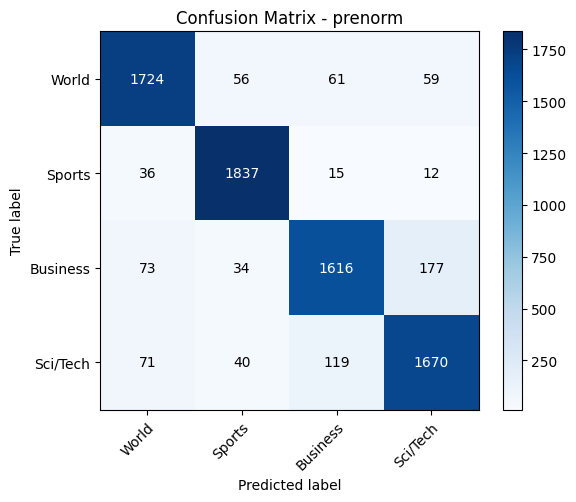

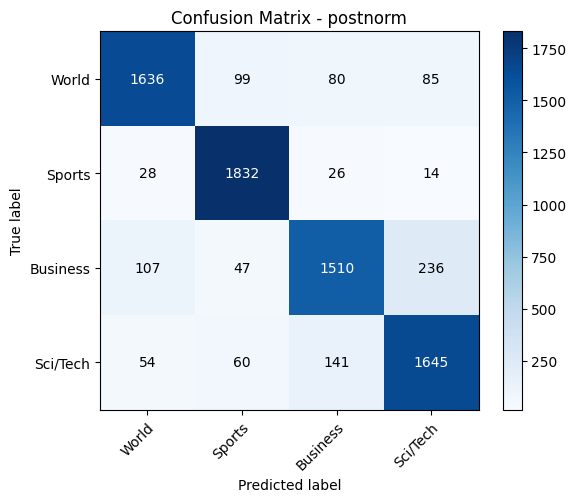

In [7]:
project_root = os.path.abspath('..')
labels = ['World', 'Sports', 'Business', 'Sci/Tech']

# Bảng kết quả
df = pd.read_csv(os.path.join(project_root, 'results', 'comparison_results.csv'))
display(df)

# Vẽ confusion matrix cho từng mô hình
with open(os.path.join(project_root, 'results', 'confusion_matrices.json'), 'r', encoding='utf-8') as f:
    cms = json.load(f)

for model_name in ['prenorm', 'postnorm']:
    cm = np.array(cms[model_name])
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)
    ax.set(
        xticks=np.arange(len(labels)),
        yticks=np.arange(len(labels)),
        xticklabels=labels,
        yticklabels=labels,
        xlabel='Predicted label',
        ylabel='True label',
        title=f'Confusion Matrix - {model_name}'
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

    thresh = cm.max() / 2.0 if cm.size > 0 else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'), ha='center', va='center', color='white' if cm[i, j] > thresh else 'black')

    plt.tight_layout()
    plt.show()